In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [2]:
from coleta import order_items, order_payments, orders

In [3]:
merge_orders = order_payments.merge(order_items, on="order_id").merge(orders, on="order_id")

### Adicionando a coluna de mes e ano

In [4]:

merge_orders['month'] = merge_orders['order_purchase_timestamp'].dt.month
merge_orders['year'] = merge_orders['order_purchase_timestamp'].dt.year
merge_orders['month_year'] = merge_orders.apply(lambda x: f"{x['month']}/{x['year']}", axis=1)

### Mantendo apenas ordens que fazem sentido para faturamento

In [5]:
merge_orders = merge_orders[merge_orders['order_status'].isin(['delivered', 'invoiced', 'shipped', 'approved'])]

### Removendo valores nulos de 'delivered'

In [6]:
merge_orders = merge_orders[merge_orders['order_status'] == 'delivered'].dropna(axis=0, how="any")

### Removendo valores nulos de 'order_purchase_timestamp' e 'order_approved_at'

In [7]:
merge_orders.dropna(subset='order_purchase_timestamp' , axis=0, how="any", inplace=True)
merge_orders.dropna(subset='order_approved_at' , axis=0, how="any", inplace=True)

- Primeira pergunta de negócio: Qual foi o faturamento total da empresa no período analisado?

In [8]:
faturamento_total = merge_orders['payment_value'].sum()
faturamento_total

np.float64(19772505.900000002)

    O faturamento da empresa no perídodo analisado foi de R$ 15.165.484,93

- Segunda pergunta de negócio: Quantos pedidos foram realizados?

In [9]:
pedidos_realizados = merge_orders.shape[0]
pedidos_realizados

115011

    Ao total foram realizados 96.454 pedidos 

- Terceira pergunta de negócio: Qual foi o ticket médio dos pedidos?

In [10]:
ticket_medio = faturamento_total / pedidos_realizados
ticket_medio

np.float64(171.91838954534785)

    O ticket médio dos pedidos é em média R$ 157,23 por venda

- Quarta pergunta de negócio: Como o faturamento evoluiu ao longo do tempo?

In [11]:
faturamento_por_ano = merge_orders.groupby('year')['payment_value'].sum().reset_index()

In [12]:
faturamento_por_ano

,year,payment_value
0,2016,61766.56
1,2017,8870627.51
2,2018,10840111.83


In [13]:
faturamento_por_mes_ano = merge_orders.groupby(['year','month'])['payment_value'].sum().reset_index().sort_values(by=['year', 'month'])

In [14]:
faturamento_por_mes_ano['month_year'] = faturamento_por_mes_ano.apply(lambda x: f"{int(x['month'])}/{int(x['year'])}", axis=1)


In [15]:
mes_ano = faturamento_por_mes_ano['month_year']

In [16]:
faturamento_por_mes_ano

,year,month,payment_value,month_year
0,2016,10,61746.94,10/2016
1,2016,12,19.62,12/2016
2,2017,1,176376.56,1/2017
3,2017,2,323815.95,2/2017
4,2017,3,505735.83,3/2017
5,2017,4,456108.32,4/2017
6,2017,5,701119.60,5/2017
7,2017,6,585400.98,6/2017
8,2017,7,716069.98,7/2017
9,2017,8,842689.94,8/2017


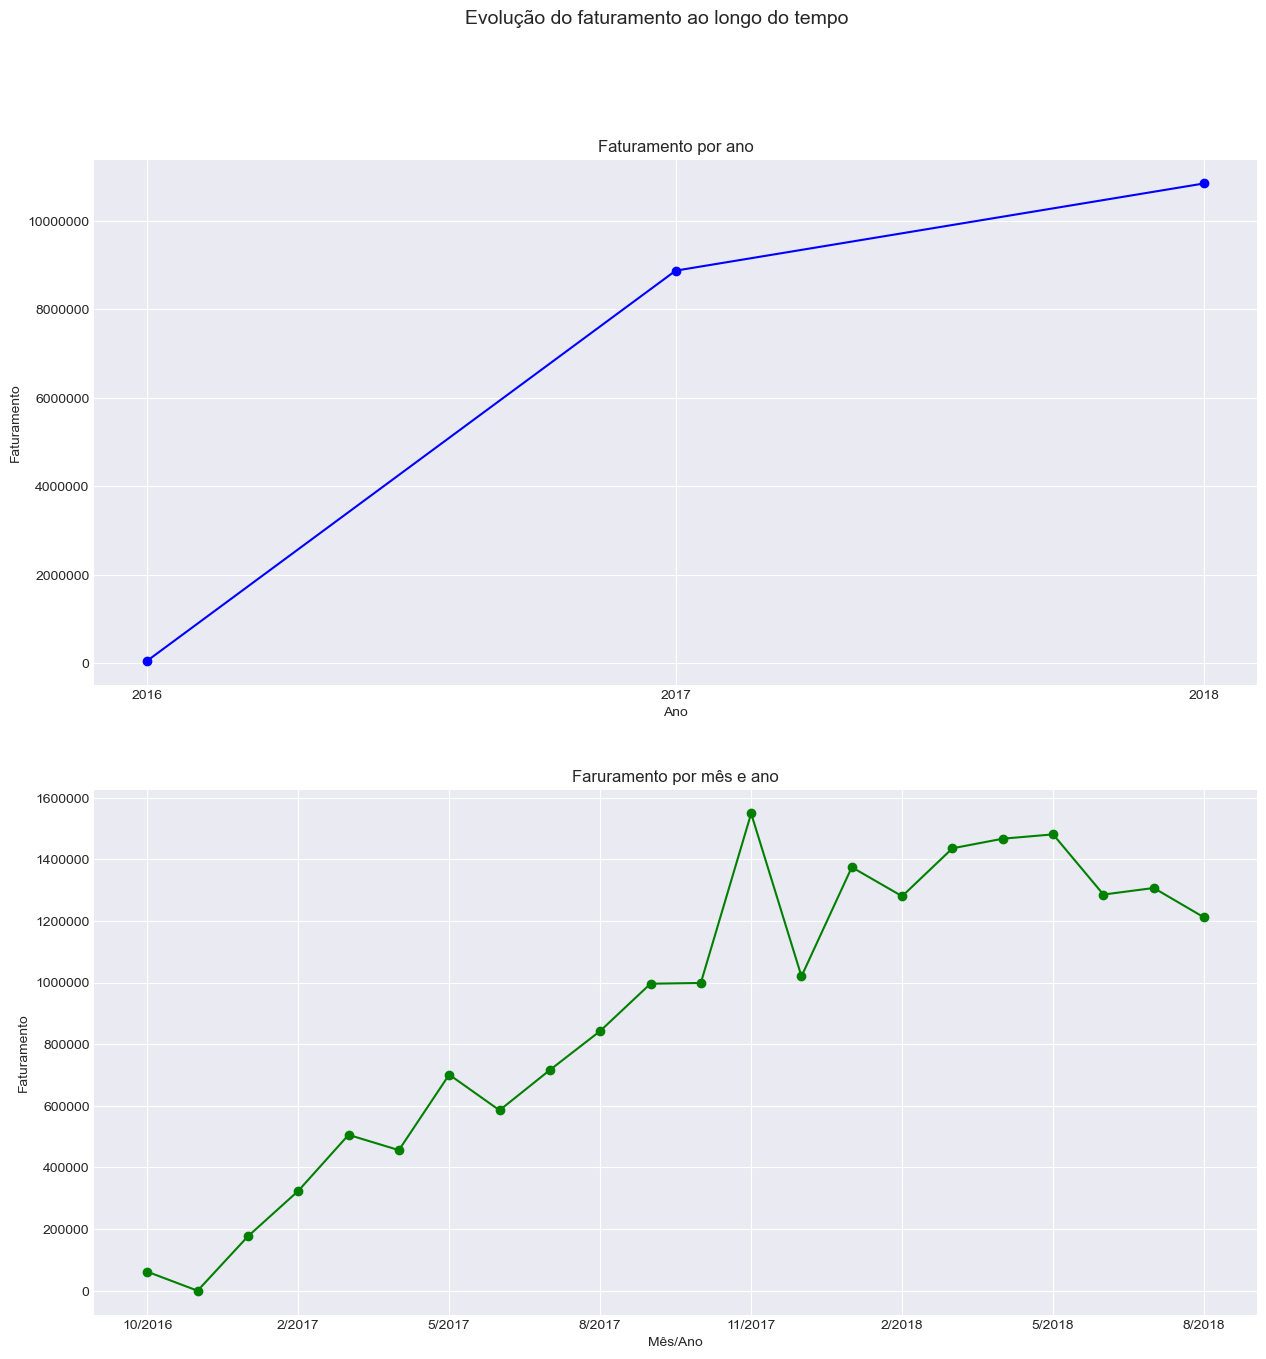

In [17]:
plt.style.use('seaborn-v0_8-darkgrid')

fig, (graf_cima, graf_baixo) = plt.subplots(2, 1, figsize=(15, 15))

fig.suptitle('Evolução do faturamento ao longo do tempo', fontsize=14)

graf_cima.plot(faturamento_por_ano['year'].astype(str), faturamento_por_ano['payment_value'], color = 'blue', marker='o')
graf_cima.set_title('Faturamento por ano')
graf_cima.set_xlabel('Ano')
graf_cima.set_ylabel('Faturamento')
graf_cima.ticklabel_format(style='plain', axis='y')

graf_baixo.plot(faturamento_por_mes_ano['month_year'], faturamento_por_mes_ano['payment_value'], color='green', marker='o')
graf_baixo.set_xlabel('Mês/Ano')
graf_baixo.set_ylabel('Faturamento')
graf_baixo.set_title('Faruramento por mês e ano')
graf_baixo.ticklabel_format(style='plain', axis='y')
graf_baixo.set_xticks(ticks = mes_ano[::3])

plt.show()